In [ ]:
# CELL 1: IMPORT LIBRARIES

import os
import glob
import zipfile
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

In [ ]:
# CELL 2: UNZIP THE DATASET

zip_path = "/content/pooled_stratified_share.zip"
extract_parent = "/content"
extract_path = "/content/pooled_stratified_share"

if not os.path.exists(zip_path):
    raise FileNotFoundError(
        f"Could not find dataset zip at: {zip_path}\n"
        "Please upload or mount the dataset first."
    )

if not os.path.exists(extract_path):
    print("Unzipping dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_parent)
else:
    print("Dataset folder already exists, skipping unzip.")

print("Dataset path:", extract_path)

Unzipping dataset...
Dataset path: /content/pooled_stratified_share


In [ ]:
# CELL 3: FIND ALL .NPZ FILES

npz_files = sorted(glob.glob(os.path.join(extract_path, "**", "*.npz"), recursive=True))

print(f"Found {len(npz_files)} .npz files.\n")

if len(npz_files) == 0:
    raise ValueError("No .npz files found. Check that the dataset unzipped correctly.")

Found 2880 .npz files.



In [ ]:
# CELL 4: INSPECT ONE EXAMPLE FILE

example_file = npz_files[0]
example_data = np.load(example_file, allow_pickle=True)

print("Example file:", example_file)
print("Keys inside file:", example_data.files)

for key in example_data.files:
    arr = example_data[key]
    print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")

Example file: /content/pooled_stratified_share/subjA2s60K-Hhm/session0BuHV4d9L3/session0BuHV4d9L3_run61u38PxBQj.npz
Keys inside file: ['roi_labels', 'timeseries', 'voxel_counts', 'run_name', 'session', 'run', 'atlas_name']
roi_labels: shape=(18,), dtype=int64
timeseries: shape=(18, 226), dtype=float64
voxel_counts: shape=(18,), dtype=int64
run_name: shape=(), dtype=<U33
session: shape=(), dtype=<U9
run: shape=(), dtype=<U5
atlas_name: shape=(), dtype=<U4


timeseries shape: (18, 226)


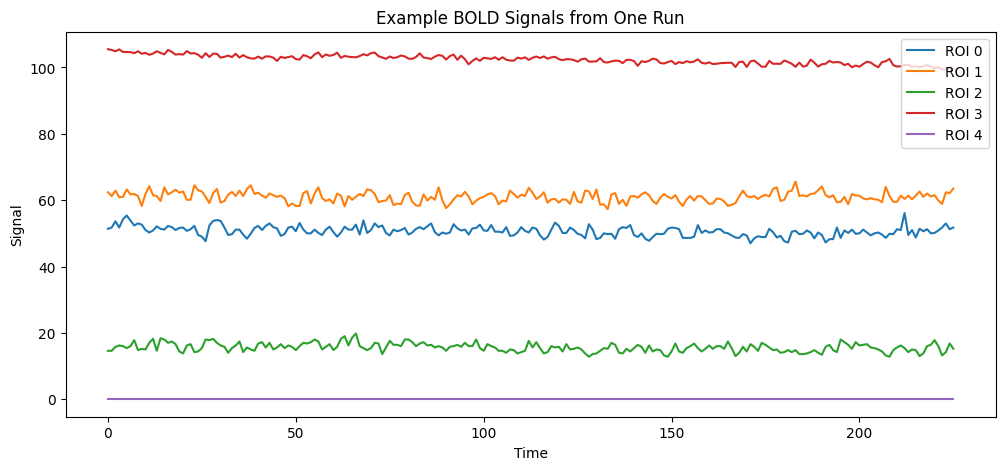

In [ ]:
# CELL 5: PLOT ONE EXAMPLE RUN

timeseries = example_data["timeseries"]   # expected shape: (ROI, time)

print("timeseries shape:", timeseries.shape)

plt.figure(figsize=(12, 5))
for roi_idx in range(min(5, timeseries.shape[0])):
    plt.plot(timeseries[roi_idx], label=f"ROI {roi_idx}")

plt.title("Example BOLD Signals from One Run")
plt.xlabel("Time")
plt.ylabel("Signal")
plt.legend()
plt.show()

In [ ]:
# CELL 6: DETERMINE ROI COUNT CONSISTENCY

roi_counts = []

for file_path in npz_files:
    data = np.load(file_path, allow_pickle=True)
    ts = data["timeseries"]
    roi_counts.append(ts.shape[0])

roi_counts = np.array(roi_counts)

print("ROI counts found in dataset:", np.unique(roi_counts))

min_rois = int(np.min(roi_counts))
print("Minimum ROI count used for modeling:", min_rois)

ROI counts found in dataset: [18 19]
Minimum ROI count used for modeling: 18


In [ ]:
# CELL 7: RUN-SAFE TRAIN TEST SPLIT
# Same logic as the linear regression notebook:
# shuffle runs, then split whole runs into train/test

run_ids = np.arange(len(npz_files))

np.random.seed(42)
np.random.shuffle(run_ids)

split_idx = int(0.8 * len(run_ids))

train_run_ids = run_ids[:split_idx]
test_run_ids = run_ids[split_idx:]

train_files = [npz_files[i] for i in train_run_ids]
test_files = [npz_files[i] for i in test_run_ids]

print("Train runs:", len(train_files))
print("Test runs:", len(test_files))

Train runs: 2304
Test runs: 576


**We use the same run-level train/test split strategy (random seed 42, 80/20 split) as the other models to ensure consistency in which runs are used for training and testing. However, the evaluation procedure differs from the linear regression and transformer models. Instead of generating sliding window samples, exponential smoothing is applied directly to each ROI time series within a test run, and only the final future point is predicted. This is because exponential smoothing is a univariate time-series model designed to forecast based on the full past sequence rather than fixed input windows. As a result, it produces one prediction per ROI per run instead of many window-based predictions.**

In [ ]:
# CELL 8: FORECASTING SETTINGS

WINDOW_SIZE = 30
HORIZON = 1

# Exponential smoothing model settings
# Start simple: no explicit trend, no seasonality
ES_TREND = None
ES_SEASONAL = None
ES_SEASONAL_PERIODS = None

print("WINDOW_SIZE:", WINDOW_SIZE)
print("HORIZON:", HORIZON)
print("TREND:", ES_TREND)
print("SEASONAL:", ES_SEASONAL)

WINDOW_SIZE: 30
HORIZON: 1
TREND: None
SEASONAL: None


In [ ]:
# CELL 9: HELPER FUNCTIONS

def zscore_per_roi(timeseries):
    mean = timeseries.mean(axis=1, keepdims=True)
    std = timeseries.std(axis=1, keepdims=True)
    return (timeseries - mean) / (std + 1e-8)


def compute_scaled_mse(train_series, y_true, y_pred):
    """
    M5-style scaled error idea:
    scale by the in-sample naive one-step squared error.

    train_series: 1D training signal
    y_true: 1D true future values
    y_pred: 1D predicted future values
    """
    if len(train_series) < 2:
        return np.nan

    naive_diffs = np.diff(train_series)
    denom = np.mean(naive_diffs ** 2)

    if denom < 1e-12:
        return np.nan

    mse = np.mean((y_true - y_pred) ** 2)
    return mse / denom


def fit_exp_smoothing_and_forecast(train_series, forecast_steps,
                                   trend=None, seasonal=None, seasonal_periods=None):
    """
    Fit exponential smoothing to one 1D train series and forecast future steps.
    """
    model = ExponentialSmoothing(
        endog=train_series,
        trend=trend,
        seasonal=seasonal,
        seasonal_periods=seasonal_periods,
        initialization_method="estimated"
    )

    fit = model.fit(optimized=True)
    forecast = fit.forecast(forecast_steps)

    return np.asarray(forecast), fit


def evaluate_one_run(file_path, window_size=30, horizon=1,
                     trend=None, seasonal=None, seasonal_periods=None,
                     min_rois=18):
    """
    For one run:
    - truncate to min_rois
    - z-score each ROI
    - split the run in time:
        training = all but last (window_size + horizon) points
        testing target = final horizon point after the last window

    We forecast the final target using only the train part.
    To make it more similar to your previous models, we use:
        train_series = ts[:train_end]
        test target   = ts[train_end + horizon - 1]

    For HORIZON=1, this predicts the next timepoint after the training segment.
    """
    data = np.load(file_path, allow_pickle=True)
    ts = data["timeseries"][:min_rois]   # (ROI, time)

    ts = zscore_per_roi(ts)

    num_rois, T = ts.shape

    train_end = T - horizon
    if train_end <= 5:
        raise ValueError(f"Run too short for forecasting: {file_path}")

    all_true = []
    all_pred = []
    all_mse = []
    all_scaled_mse = []

    for roi_idx in range(num_rois):
        roi_series = ts[roi_idx]

        train_series = roi_series[:train_end]
        test_true = roi_series[train_end : train_end + horizon]

        try:
            test_pred, fit = fit_exp_smoothing_and_forecast(
                train_series=train_series,
                forecast_steps=horizon,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=seasonal_periods
            )
        except Exception:
            # fallback in case fitting fails
            test_pred = np.repeat(train_series[-1], horizon)

        mse = np.mean((test_true - test_pred) ** 2)
        scaled_mse = compute_scaled_mse(train_series, test_true, test_pred)

        all_true.append(test_true)
        all_pred.append(test_pred)
        all_mse.append(mse)
        all_scaled_mse.append(scaled_mse)

    return {
        "y_true": np.array(all_true),              # shape: (ROI, horizon)
        "y_pred": np.array(all_pred),              # shape: (ROI, horizon)
        "roi_mse": np.array(all_mse),              # shape: (ROI,)
        "roi_scaled_mse": np.array(all_scaled_mse) # shape: (ROI,)
    }

The input data consists of pre-parcellated fMRI time series with shape (number of ROIs × timepoints). Each run is first standardized using per-ROI z-scoring. The data is then parsed into supervised learning samples using a sliding window approach, where a sequence of past timepoints across all ROIs is used to predict the next timepoint. These samples are aggregated across runs, and a run-level split is used to ensure that training and testing are performed on separate runs, preventing data leakage.

In [ ]:
# CELL 10: SANITY CHECK ONE TEST RUN

one_result = evaluate_one_run(
    file_path=test_files[0],
    window_size=WINDOW_SIZE,
    horizon=HORIZON,
    trend=ES_TREND,
    seasonal=ES_SEASONAL,
    seasonal_periods=ES_SEASONAL_PERIODS,
    min_rois=min_rois
)

print("y_true shape:", one_result["y_true"].shape)
print("y_pred shape:", one_result["y_pred"].shape)
print("roi_mse shape:", one_result["roi_mse"].shape)
print("roi_scaled_mse shape:", one_result["roi_scaled_mse"].shape)

print("Mean ROI MSE on this run:", np.nanmean(one_result["roi_mse"]))
print("Mean ROI scaled MSE on this run:", np.nanmean(one_result["roi_scaled_mse"]))

y_true shape: (18, 1)
y_pred shape: (18, 1)
roi_mse shape: (18,)
roi_scaled_mse shape: (18,)
Mean ROI MSE on this run: 0.5379961319845529
Mean ROI scaled MSE on this run: 0.9456421778852516


In [ ]:
# CELL 11: EVALUATE ALL TEST RUNS

all_run_results = []

for i, file_path in enumerate(test_files):
    try:
        result = evaluate_one_run(
            file_path=file_path,
            window_size=WINDOW_SIZE,
            horizon=HORIZON,
            trend=ES_TREND,
            seasonal=ES_SEASONAL,
            seasonal_periods=ES_SEASONAL_PERIODS,
            min_rois=min_rois
        )

        all_run_results.append({
            "file_path": file_path,
            "mean_roi_mse": np.nanmean(result["roi_mse"]),
            "mean_roi_scaled_mse": np.nanmean(result["roi_scaled_mse"]),
            "roi_mse": result["roi_mse"],
            "roi_scaled_mse": result["roi_scaled_mse"],
            "y_true": result["y_true"],
            "y_pred": result["y_pred"]
        })

    except Exception as e:
        print(f"Skipping run {i} due to error: {file_path}")
        print("Error:", e)

print("Successfully evaluated test runs:", len(all_run_results))

Successfully evaluated test runs: 576


**Because exponential smoothing is evaluated using a single forecast per ROI per run, while the other models are evaluated on all sliding windows, its test error is not directly identical in structure. However, the same train/test runs are used, so the comparison remains meaningful as a baseline for forecasting performance.**

# **Statistics**

In [ ]:
# CELL 12: ORGANIZE EXPONENTIAL SMOOTHING TEST OUTPUTS
# This cell gathers the true values, predicted values, and run labels
# into consistent variable names so the later statistics cells match
# the structure used in the linear regression and transformer notebooks.
#
# Important note:
# Exponential smoothing is evaluated differently from the other two models.
# Here, each test run produces one forecast per ROI (rather than many sliding-window samples).

import numpy as np

Y_test_all = np.array([r["y_true"].reshape(-1) for r in all_run_results])   # shape: (num_test_runs, num_rois)
Y_pred_all = np.array([r["y_pred"].reshape(-1) for r in all_run_results])   # shape: (num_test_runs, num_rois)

# one row in Y_test_all / Y_pred_all corresponds to one held-out test run
test_sample_run_ids = np.arange(len(all_run_results))

print("Y_test_all shape:", Y_test_all.shape)
print("Y_pred_all shape:", Y_pred_all.shape)
print("test_sample_run_ids shape:", test_sample_run_ids.shape)
print("Number of held-out test runs:", len(test_sample_run_ids))

Y_test_all shape: (576, 18)
Y_pred_all shape: (576, 18)
test_sample_run_ids shape: (576,)
Number of held-out test runs: 576


In [ ]:
# CELL 13: OVERALL TEST MSE AND SCALED MSE
# This cell computes:
# 1. Overall test MSE across all held-out runs and all ROIs
# 2. Overall scaled MSE across all held-out runs and all ROIs
#
# Since exponential smoothing produces one forecast per ROI per test run,
# these summary values are based on run-level forecasts rather than sliding-window samples.

from sklearn.metrics import mean_squared_error

overall_mse = mean_squared_error(Y_test_all, Y_pred_all)

# collect all ROI-level scaled MSE values from all runs
all_scaled_values = []

for r in all_run_results:
    vals = np.array(r["roi_scaled_mse"], dtype=float)
    all_scaled_values.extend(vals[~np.isnan(vals)])

all_scaled_values = np.array(all_scaled_values)

scaled_mse = np.mean(all_scaled_values)

print("Overall Test MSE:", overall_mse)
print("Scaled MSE:", scaled_mse)

Overall Test MSE: 0.7055851582668028
Scaled MSE: 1.1206842256490355


In [ ]:
# CELL 14: PER-ROI PERFORMANCE STATISTICS
# This cell computes test MSE separately for each ROI across the held-out test runs.
# It helps us see whether some ROIs are easier or harder to predict using exponential smoothing.

roi_mse = np.mean((Y_test_all - Y_pred_all) ** 2, axis=0)

print("Per-ROI MSE:")
for roi_idx, val in enumerate(roi_mse):
    print(f"ROI {roi_idx}: {val:.6f}")

print("\nSummary across ROIs:")
print("Mean ROI MSE:", np.mean(roi_mse))
print("Std ROI MSE:", np.std(roi_mse))
print("Best ROI MSE:", np.min(roi_mse))
print("Worst ROI MSE:", np.max(roi_mse))

Per-ROI MSE:
ROI 0: 0.908868
ROI 1: 0.852203
ROI 2: 0.646777
ROI 3: 0.426723
ROI 4: 0.928147
ROI 5: 0.548280
ROI 6: 0.962461
ROI 7: 0.849161
ROI 8: 1.098073
ROI 9: 1.044528
ROI 10: 0.876484
ROI 11: 0.391662
ROI 12: 0.480170
ROI 13: 0.286856
ROI 14: 0.541994
ROI 15: 0.559185
ROI 16: 0.573828
ROI 17: 0.725134

Summary across ROIs:
Mean ROI MSE: 0.7055851582668028
Std ROI MSE: 0.2349572602825048
Best ROI MSE: 0.28685609395557005
Worst ROI MSE: 1.0980730457558703


In [ ]:
# CELL 15: RUN-LEVEL PERFORMANCE ACROSS HELD-OUT TEST RUNS
# This cell computes one MSE value per held-out test run.
# For exponential smoothing, this is especially natural because each test run
# produces one forecast per ROI, so each run already has a single run-level error.

run_level_mse = np.array([r["mean_roi_mse"] for r in all_run_results], dtype=float)
run_level_num_samples = np.array([Y_test_all.shape[1]] * len(all_run_results))  # one forecast per ROI

print("Run-level MSE for each held-out test run:")
for i, mse_val in enumerate(run_level_mse):
    print(f"Run {i}: MSE = {mse_val:.6f} | Samples = {run_level_num_samples[i]}")

print("\nRun-level summary:")
print("Mean run MSE:", np.mean(run_level_mse))
print("Std run MSE:", np.std(run_level_mse))
print("Best run MSE:", np.min(run_level_mse))
print("Worst run MSE:", np.max(run_level_mse))

Run-level MSE for each held-out test run:
Run 0: MSE = 0.537996 | Samples = 18
Run 1: MSE = 0.467370 | Samples = 18
Run 2: MSE = 0.635773 | Samples = 18
Run 3: MSE = 1.356310 | Samples = 18
Run 4: MSE = 0.647488 | Samples = 18
Run 5: MSE = 0.189600 | Samples = 18
Run 6: MSE = 0.438157 | Samples = 18
Run 7: MSE = 0.699259 | Samples = 18
Run 8: MSE = 0.206934 | Samples = 18
Run 9: MSE = 1.556138 | Samples = 18
Run 10: MSE = 1.493166 | Samples = 18
Run 11: MSE = 0.284809 | Samples = 18
Run 12: MSE = 0.309206 | Samples = 18
Run 13: MSE = 0.521645 | Samples = 18
Run 14: MSE = 0.655337 | Samples = 18
Run 15: MSE = 0.376291 | Samples = 18
Run 16: MSE = 1.970356 | Samples = 18
Run 17: MSE = 0.765829 | Samples = 18
Run 18: MSE = 0.168202 | Samples = 18
Run 19: MSE = 0.278689 | Samples = 18
Run 20: MSE = 0.713540 | Samples = 18
Run 21: MSE = 0.417577 | Samples = 18
Run 22: MSE = 0.871815 | Samples = 18
Run 23: MSE = 0.679525 | Samples = 18
Run 24: MSE = 0.418796 | Samples = 18
Run 25: MSE = 1.92

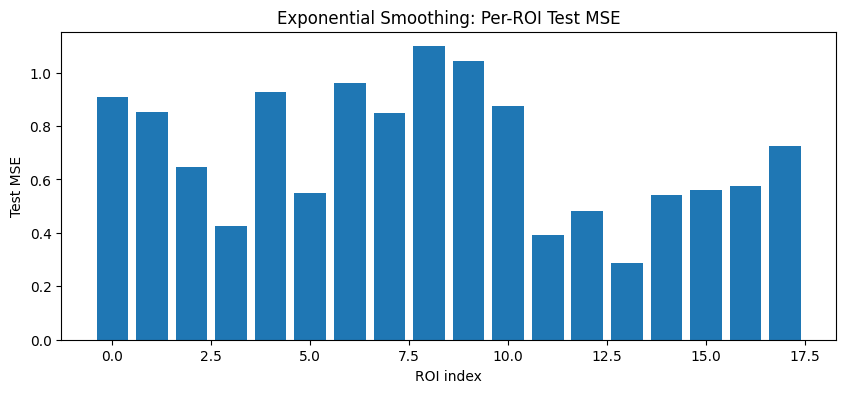

In [ ]:
# CELL 16: PLOT PER-ROI MSE
# This plot shows how exponential smoothing prediction error changes across ROIs.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(np.arange(len(roi_mse)), roi_mse)
plt.xlabel("ROI index")
plt.ylabel("Test MSE")
plt.title("Exponential Smoothing: Per-ROI Test MSE")
plt.show()

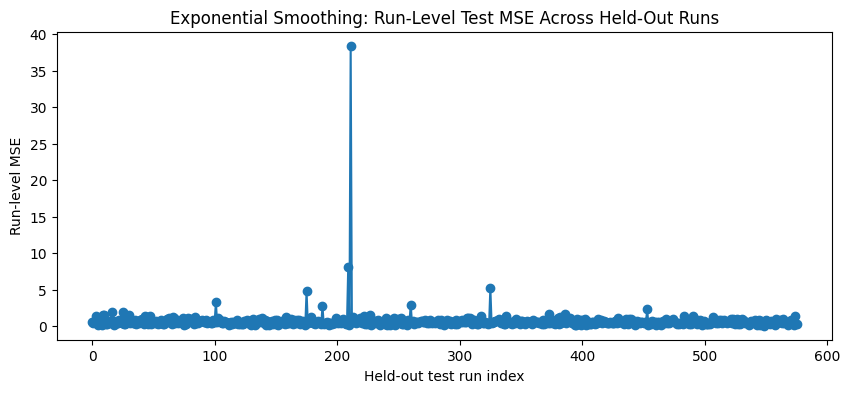

In [ ]:
# CELL 17: PLOT RUN-LEVEL MSE
# This plot shows how exponential smoothing performance varies across held-out test runs.

plt.figure(figsize=(10, 4))
plt.plot(run_level_mse, marker='o')
plt.xlabel("Held-out test run index")
plt.ylabel("Run-level MSE")
plt.title("Exponential Smoothing: Run-Level Test MSE Across Held-Out Runs")
plt.show()

In [ ]:
# CELL 18: SAVE EXPONENTIAL SMOOTHING STATISTICS FOR LATER MODEL COMPARISON
# This cell saves the outputs and summary statistics using the same key names
# as the linear regression and transformer notebooks, so all three files
# can later be loaded into one separate comparison notebook.

exponential_smoothing_results = {
    "model_name": "Exponential Smoothing",
    "window_size": WINDOW_SIZE,
    "horizon": HORIZON,
    "num_rois": min_rois,

    "overall_mse": overall_mse,
    "scaled_mse": scaled_mse,

    "roi_mse": roi_mse,
    "mean_roi_mse": np.mean(roi_mse),
    "std_roi_mse": np.std(roi_mse),

    "run_level_mse": run_level_mse,
    "mean_run_mse": np.mean(run_level_mse),
    "std_run_mse": np.std(run_level_mse),

    "Y_test_all": Y_test_all,
    "Y_pred_all": Y_pred_all,
    "test_sample_run_ids": test_sample_run_ids,
    "test_runs": test_sample_run_ids,
    "test_files": np.array([r["file_path"] for r in all_run_results], dtype=object)
}

np.save("/content/exponential_smoothing_statistics.npy", exponential_smoothing_results, allow_pickle=True)

print("Saved to: /content/exponential_smoothing_statistics.npy")

Saved to: /content/exponential_smoothing_statistics.npy


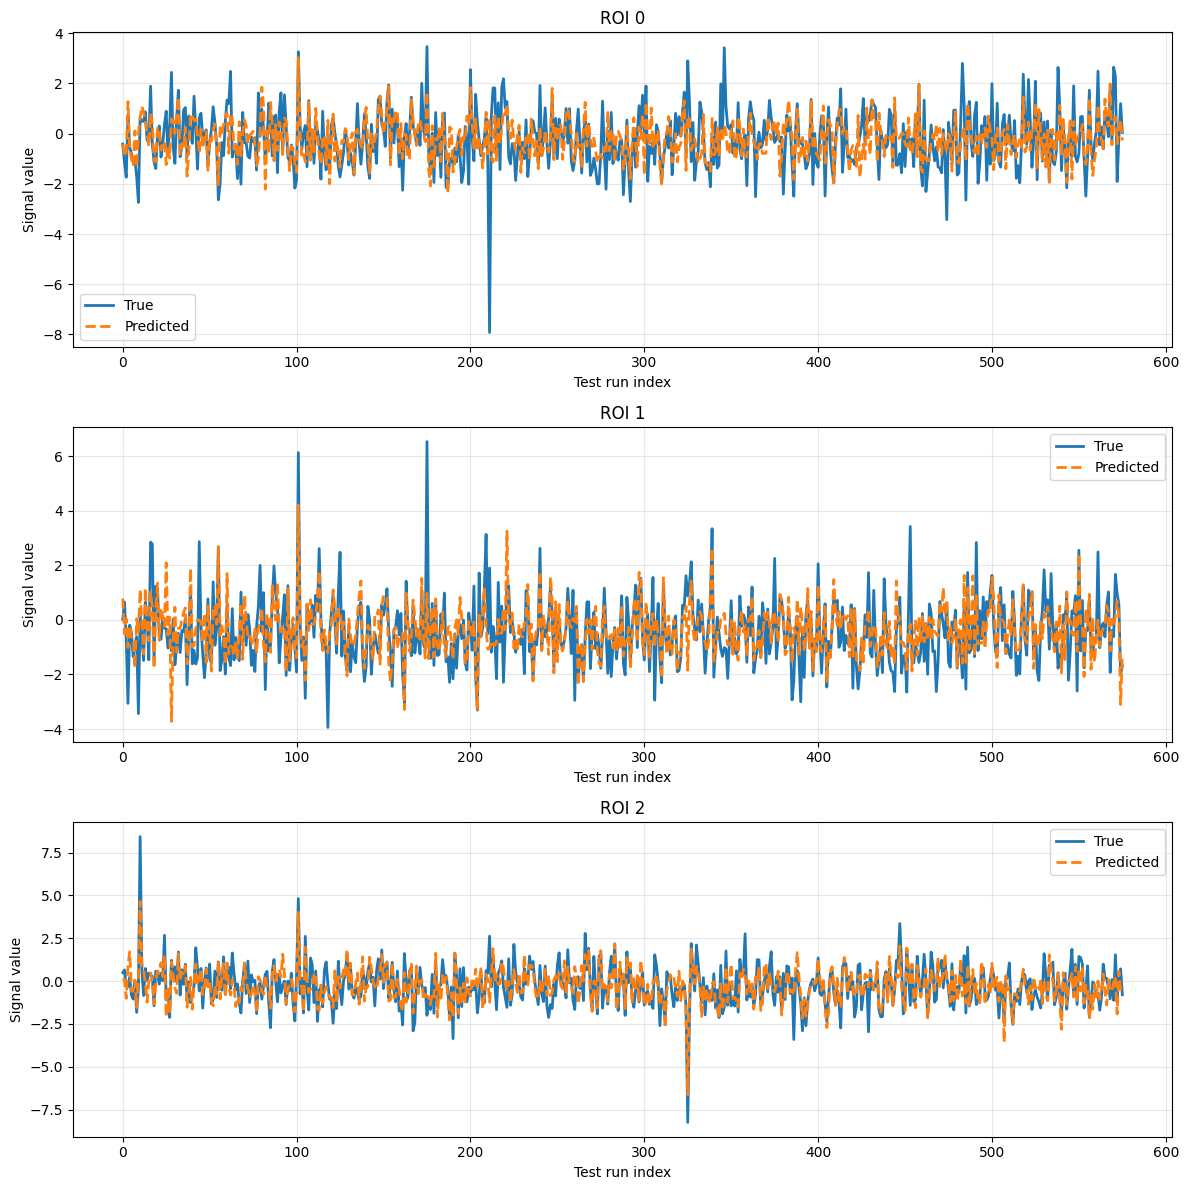

In [ ]:
# CELL: TRUE VS PREDICTED (SEPARATE PLOTS PER ROI)

import matplotlib.pyplot as plt
import numpy as np

# Select ROIs to visualize
rois_to_plot = [0, 1, 2]  # change as needed

x = np.arange(Y_test_all.shape[0])  # test run index

num_rois = len(rois_to_plot)

plt.figure(figsize=(12, 4 * num_rois))

for i, roi in enumerate(rois_to_plot):
    plt.subplot(num_rois, 1, i + 1)

    plt.plot(x, Y_test_all[:, roi], linewidth=2, label="True")
    plt.plot(x, Y_pred_all[:, roi], linestyle='--', linewidth=2, label="Predicted")

    plt.title(f"ROI {roi}")
    plt.xlabel("Test run index")
    plt.ylabel("Signal value")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()